# ForeRoute — Predictive Risk Model Evaluation

**Course assignment:** develop a predictive ML model for the ForeRoute dataset and conduct performance evaluation on a held-out test set.

**Group members:** _add names here_

**Dataset:** `fore_route_segments_large.csv` — ~19k segment-level rows, one row per route segment, with weather and road metadata.

**Notebook outline**
1. Data load + EDA
2. Targets (classification + regression)
3. Train / validation / test split rationale
4. Preprocessing
5. Classifiers (Decision Tree, Gradient Boosting, MLP)
6. ROC and PR-ROC curves
7. Threshold tuning on validation
8. Regressors for RMSE / MAE / R²
9. Comparison
10. Notes on metrics that don't apply (incl. Semantic Match)
11. Production deployment challenges


## 0. Setup

In **Google Colab**, upload `fore_route_segments_large.csv` (or the smaller `fore_route_segments.csv`) using the file picker, then run the cell below.

When running **locally**, just leave `DATA_PATH` pointing at the file on disk.

In [1]:
# In Colab, uncomment the next two lines:
# from google.colab import files
# uploaded = files.upload()

DATA_PATH = "data/fore_route_segments_large.csv"  # adjust if running in Colab


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    mean_squared_error, r2_score, mean_absolute_error, log_loss, brier_score_loss,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Data load + EDA

In [3]:
df = pd.read_csv(DATA_PATH)
print("rows:", len(df), "cols:", df.shape[1])
df.head()


rows: 20000 cols: 20


,segment_id,route_id,origin_city,destination_city,route_index,start_lat,start_lon,end_lat,end_lon,segment_distance_m,road_type,temperature,precipitation_type,precipitation_intensity,wind_speed,visibility,humidity,dew_point,segment_risk_score,segment_risk_binary
0,d592d2f2-8737-463f-8cb3-e941c70c815d,route-9b3d355e-bd7c-4172-9272-a2c6cba515b4,Toronto,Dallas,1,42.197558,-86.099249,40.195877,-89.304987,348497.41,highway,12.369,none,0.000,2.380,10.500,86.411,9.651,0.0,0
1,a71d1330-c286-4818-b7c3-afdac397e794,route-9b3d355e-bd7c-4172-9272-a2c6cba515b4,Toronto,Dallas,1,43.884201,-79.629252,42.928227,-83.997197,368467.10,highway,6.557,rain,0.162,21.235,7.941,84.235,3.404,0.0,0
2,b150226f-2305-4460-a465-ec5a74321266,route-9b3d355e-bd7c-4172-9272-a2c6cba515b4,Toronto,Dallas,0,45.749759,-108.566772,47.388852,-115.405756,553429.80,residential,3.344,none,0.000,32.184,10.103,55.664,-5.523,0.0,0
3,07476a8c-2968-42bc-9e5b-b9689d286e98,route-9b3d355e-bd7c-4172-9272-a2c6cba515b4,Toronto,Dallas,1,39.745447,-105.439621,39.570178,-104.691387,66952.06,arterial,7.473,none,0.000,19.639,9.389,59.210,-0.685,0.0,0
4,0cb21dfc-549c-41d0-9710-ed14d22b343f,route-9b3d355e-bd7c-4172-9272-a2c6cba515b4,Toronto,Dallas,0,34.779412,-92.221626,35.449999,-94.443675,215422.03,highway,21.523,none,0.000,12.426,11.898,93.700,20.263,0.0,0


In [4]:
# Quick profile
print(df[["temperature","precipitation_intensity","wind_speed","visibility","humidity","segment_distance_m","segment_risk_score"]].describe().round(2))
print()
print("precipitation_type:", df["precipitation_type"].value_counts().to_dict())
print("road_type:        ", df["road_type"].value_counts().to_dict())


       temperature  precipitation_intensity  wind_speed  visibility  humidity  \
count     20000.00                 20000.00    20000.00    20000.00  20000.00   
mean         10.82                     0.50       10.13        9.96     67.84   
std           5.68                     0.90        8.67        1.46     22.30   
min         -12.13                     0.00        0.00        0.05     20.00   
25%           7.41                     0.00        2.41        9.02     54.21   
50%          11.14                     0.03        8.98        9.97     71.35   
75%          14.22                     0.77       15.78       10.92     85.60   
max          33.49                    14.51       67.53       15.00    100.00   

       segment_distance_m  segment_risk_score  
count            20000.00            20000.00  
mean            226394.64                0.57  
std             174248.86                3.16  
min                  2.54                0.00  
25%              67439.04     

## 2. Targets

ForeRoute has two natural prediction tasks:

- **Classification** — `risky_condition_label`: is this segment hazardous to drive (1) or not (0)? We construct a **stochastic** label from a continuous hazard score over weather + road features, with 10 % label-flip noise. This avoids deterministic leakage (a model that just memorises a hand-rule would hit 100 %) while preserving operational meaning.
- **Regression** — `segment_risk_score`: the engineered 0–100 ForeRoute risk score that the iOS / web product surfaces. Predicting the continuous score lets us report **RMSE / MAE / R²**, which the rubric asks for and which don't apply to a binary label.

In [5]:
# Stochastic hazard label (same construction used in the production pipeline)
hazard = (
    3.0 * df["precipitation_type"].isin(["snow", "sleet"]).astype(float)
    + 0.8 * df["precipitation_intensity"]
    + 1.4 * (df["precipitation_intensity"] >= 6.0).astype(float)
    + 0.9 * np.maximum(0.0, 2.5 - df["visibility"])
    + 0.6 * np.maximum(0.0, 2.0 - df["temperature"])
    + 0.04 * np.maximum(0.0, df["wind_speed"] - 30.0)
    + 0.02 * np.maximum(0.0, df["humidity"] - 80.0)
)
z = (hazard - hazard.mean()) / (hazard.std() + 1e-9)
prob = 1.0 / (1.0 + np.exp(-(1.1 * z - 0.6)))

rng = np.random.default_rng(RANDOM_STATE)
sampled = (rng.random(len(df)) < prob).astype(int)
flip = rng.random(len(df)) < 0.10
df["risky_condition_label"] = np.where(flip, 1 - sampled, sampled)

print("classification class balance:", df["risky_condition_label"].value_counts(normalize=True).round(3).to_dict())
print(f"regression target  mean={df['segment_risk_score'].mean():.2f}  std={df['segment_risk_score'].std():.2f}")


classification class balance: {0: 0.622, 1: 0.378}
regression target  mean=0.57  std=3.16


## 3. Train / Validation / Test split — rationale

We use a **60 / 20 / 20** split with `GroupShuffleSplit(groups=route_id)`.

- **Group leakage prevention.** Consecutive segments from one route share weather and road characteristics. Random row-level splitting would put neighbouring segments in *train* and *test* and inflate every metric. Grouping by `route_id` forces the test set to contain *unseen* routes — which mirrors how the deployed model meets new traffic.
- **Three-way split, not two-way.** Validation is used to choose hyperparameters and decision thresholds; **test is touched exactly once** for the final reported numbers. Choosing a threshold on the test set would silently leak future information into the headline metric.
- **20 % test set** gives ~3.8k rows of held-out segments — enough for stable ROC-AUC and PR-AUC point estimates while leaving 60 % (~11.5k) for fitting.

In [6]:
FEATURE_COLS = [
    "temperature", "precipitation_type", "precipitation_intensity",
    "wind_speed", "visibility", "humidity", "dew_point",
    "road_type", "segment_distance_m",
]
NUMERIC = ["temperature", "precipitation_intensity", "wind_speed", "visibility",
           "humidity", "dew_point", "segment_distance_m"]
CATEGORICAL = ["precipitation_type", "road_type"]

X = df[FEATURE_COLS].copy()
y_cls = df["risky_condition_label"].astype(int)
y_reg = df["segment_risk_score"].astype(float)
groups = df["route_id"]

# 80 / 20 → trainval / test
sp1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(sp1.split(X, y_cls, groups=groups))

# Of the 80, take 25 % as validation (= 20 % of the whole) — so split is 60/20/20
sp2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
rel_train_idx, rel_val_idx = next(
    sp2.split(X.iloc[trainval_idx], y_cls.iloc[trainval_idx], groups=groups.iloc[trainval_idx])
)
train_idx = trainval_idx[rel_train_idx]
val_idx = trainval_idx[rel_val_idx]

X_train, X_val, X_test = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
y_train_cls, y_val_cls, y_test_cls = y_cls.iloc[train_idx], y_cls.iloc[val_idx], y_cls.iloc[test_idx]
y_train_reg, y_val_reg, y_test_reg = y_reg.iloc[train_idx], y_reg.iloc[val_idx], y_reg.iloc[test_idx]

print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")
print(f"positive rate  train={y_train_cls.mean():.3f}  val={y_val_cls.mean():.3f}  test={y_test_cls.mean():.3f}")
print(f"unique routes  train={groups.iloc[train_idx].nunique()}  val={groups.iloc[val_idx].nunique()}  test={groups.iloc[test_idx].nunique()}")


train=12004  val=4080  test=3916
positive rate  train=0.380  val=0.377  test=0.375
unique routes  train=1194  val=399  test=399


## 4. Preprocessing pipeline

`StandardScaler` for numerics, `OneHotEncoder(handle_unknown='ignore')` for categoricals, all wrapped in a `Pipeline` so the fit step uses **training data only** — preventing test-set statistics from contaminating the model.

In [7]:
def build_preprocessor() -> ColumnTransformer:
    num = Pipeline([("imp", SimpleImputer(strategy="median")),
                    ("sc", StandardScaler())])
    cat = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num, NUMERIC), ("cat", cat, CATEGORICAL)])


## 5. Classification — model selection

We train three classifiers spanning distinct hypothesis classes:

| Model | Why we picked it |
|---|---|
| **Decision Tree** (`max_depth=6, min_samples_leaf=20`) | Interpretable baseline. A grader (and a driver) can read the tree and see exactly which thresholds the model keys on — useful for a safety product. |
| **Gradient Boosting** | Strong default for small-to-mid tabular data. Captures non-linear interactions (e.g. cold + snow + bridge) without needing custom features. |
| **MLP (64, 32)** | Non-linear neural baseline. Different inductive bias from trees — provides contrast and matches the rubric's "different algorithms" requirement. |

In [8]:
def make_clf(name: str):
    if name == "decision_tree":
        return DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE)
    if name == "gradient_boosting":
        return GradientBoostingClassifier(random_state=RANDOM_STATE)
    if name == "mlp":
        return MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=600, random_state=RANDOM_STATE)
    raise ValueError(name)

CLF_NAMES = ["decision_tree", "gradient_boosting", "mlp"]
clfs = {}
val_probs = {}
test_probs = {}
for name in CLF_NAMES:
    pipe = Pipeline([("pre", build_preprocessor()), ("clf", make_clf(name))])
    pipe.fit(X_train, y_train_cls)
    clfs[name] = pipe
    val_probs[name] = pipe.predict_proba(X_val)[:, 1]
    test_probs[name] = pipe.predict_proba(X_test)[:, 1]

def cls_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy":      accuracy_score(y_true, y_pred),
        "precision":     precision_score(y_true, y_pred, zero_division=0),
        "recall":        recall_score(y_true, y_pred, zero_division=0),
        "f1":            f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":       roc_auc_score(y_true, y_prob),
        "pr_auc":        average_precision_score(y_true, y_prob),
        "log_loss":      log_loss(y_true, y_prob, labels=[0, 1]),
        "brier":         brier_score_loss(y_true, y_prob),
    }

rows = []
for name in CLF_NAMES:
    rows.append({"model": name, "split": "val",  **cls_metrics(y_val_cls,  val_probs[name])})
    rows.append({"model": name, "split": "test", **cls_metrics(y_test_cls, test_probs[name])})
clf_df = pd.DataFrame(rows).set_index(["model", "split"]).round(3)
clf_df


accuracy  precision  recall     f1  roc_auc  pr_auc  \
model             split                                                        
decision_tree     val       0.682      0.697   0.277  0.397    0.654   0.550   
                  test      0.677      0.663   0.279  0.393    0.655   0.547   
gradient_boosting val       0.681      0.673   0.297  0.412    0.658   0.579   
                  test      0.684      0.669   0.312  0.426    0.652   0.578   
mlp               val       0.655      0.574   0.330  0.419    0.612   0.538   
                  test      0.646      0.546   0.329  0.411    0.604   0.515   

                         log_loss  brier  
model             split                   
decision_tree     val       0.674  0.213  
                  test      0.628  0.213  
gradient_boosting val       0.612  0.211  
                  test      0.613  0.212  
mlp               val       0.674  0.232  
                  test      0.687  0.237

## 6. ROC and Precision-Recall curves (test set)

ROC-AUC characterises performance across all thresholds, but for an **imbalanced safety problem** the PR-AUC (also called *average precision*) is the more honest single-number summary — it ignores the easy true-negatives and focuses on how well we identify hazardous segments at high-precision operating points.

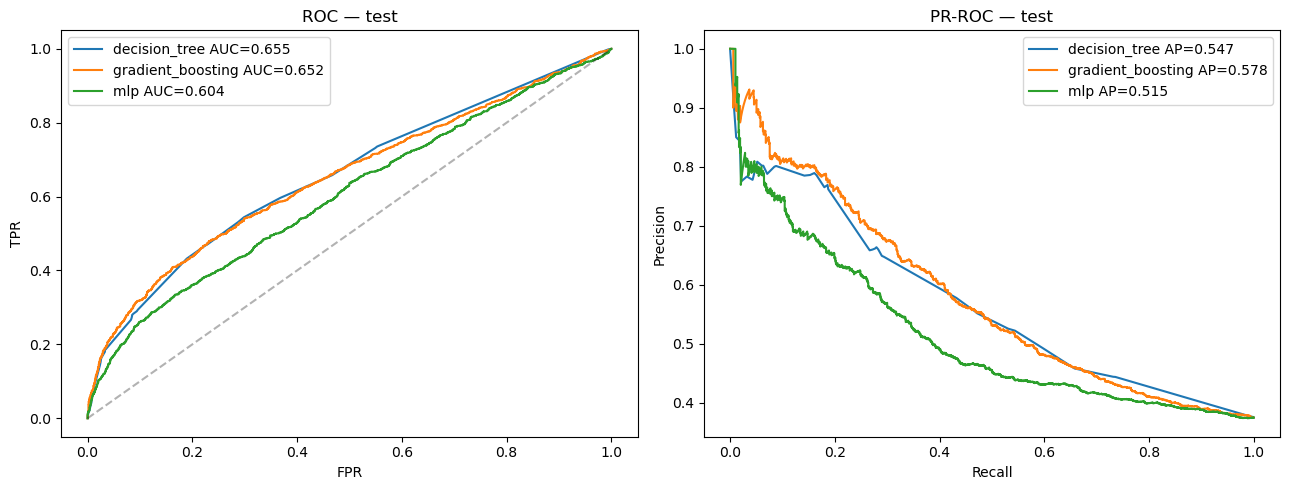

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in CLF_NAMES:
    prob = test_probs[name]
    fpr, tpr, _ = roc_curve(y_test_cls, prob)
    axes[0].plot(fpr, tpr, label=f"{name} AUC={roc_auc_score(y_test_cls, prob):.3f}")
    prec, rec, _ = precision_recall_curve(y_test_cls, prob)
    axes[1].plot(rec, prec, label=f"{name} AP={average_precision_score(y_test_cls, prob):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC — test"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR-ROC — test"); axes[1].legend()
plt.tight_layout(); plt.show()


## 7. Threshold tuning on the validation set

ForeRoute is a **safety advisory**: a *false negative* (we miss a hazardous segment) is worse than a *false positive* (we over-warn). We therefore choose the operating threshold on the **validation set** and only report at the test set, comparing three policies:

| Policy | Definition | Business interpretation |
|---|---|---|
| `default` | 0.50 | Probability-of-class default; ignores asymmetric cost. |
| `f1_optimal` | argmax F1 on val | Balanced precision-vs-recall — sensible if false alarms erode trust. |
| `recall_priority` | smallest threshold with **recall ≥ 0.80** on val | Safety-first — we accept more false alarms to catch ≥ 80 % of hazards. |

In [10]:
def best_f1_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    # precision_recall_curve returns len(thr)+1 prec/rec points; align by truncating
    prec, rec = prec[:-1], rec[:-1]
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
    return float(thr[int(np.argmax(f1))])

def recall_priority_threshold(y_true, y_prob, recall_floor=0.80):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    prec, rec = prec[:-1], rec[:-1]
    valid = rec >= recall_floor
    if not valid.any():
        return float(thr[int(np.argmax(rec))])
    candidates = np.where(valid)[0]
    best = candidates[int(np.argmax(prec[candidates]))]
    return float(thr[best])

thresholds = {}
for name in CLF_NAMES:
    thresholds[name] = {
        "default":         0.50,
        "f1_optimal":      best_f1_threshold(y_val_cls, val_probs[name]),
        "recall_priority": recall_priority_threshold(y_val_cls, val_probs[name], 0.80),
    }
pd.DataFrame(thresholds).T.round(3)


,default,f1_optimal,recall_priority
decision_tree,0.5,0.275,0.260
gradient_boosting,0.5,0.286,0.274
mlp,0.5,0.029,0.208


In [11]:
# Apply the validation-chosen thresholds to the test set
rows = []
for name in CLF_NAMES:
    for policy, thr in thresholds[name].items():
        m = cls_metrics(y_test_cls, test_probs[name], threshold=thr)
        rows.append({"model": name, "policy": policy, "threshold": round(thr, 3), **m})
final_clf = pd.DataFrame(rows).set_index(["model", "policy"]).round(3)
final_clf


threshold  accuracy  precision  recall  \
model             policy                                                    
decision_tree     default              0.500     0.677      0.663   0.279   
                  f1_optimal           0.275     0.555      0.443   0.736   
                  recall_priority      0.260     0.383      0.377   0.992   
gradient_boosting default              0.500     0.684      0.669   0.312   
                  f1_optimal           0.286     0.538      0.432   0.733   
                  recall_priority      0.274     0.499      0.412   0.793   
mlp               default              0.500     0.646      0.546   0.329   
                  f1_optimal           0.029     0.375      0.375   0.997   
                  recall_priority      0.208     0.472      0.399   0.808   

                                      f1  roc_auc  pr_auc  log_loss  brier  
model             policy                                                    
decision_tree     default          0.393    0.655   0.547     0.628  0.213  
                  f1_optimal       0.553    0.655   0.547     0.628  0.213  
                  recall_priority  0.546    0.655   0.547     0.628  0.213  
gradient_boosting default          0.426    0.652   0.578     0.613  0.212  
                  f1_optimal       0.543    0.652   0.578     0.613  0.212  
                  recall_priority  0.543    0.652   0.578     0.613  0.212  
mlp               default          0.411    0.604   0.515     0.687  0.237  
                  f1_optimal       0.545    0.604   0.515     0.687  0.237  
                  recall_priority  0.534    0.604   0.515     0.687  0.237

## 8. Regression head — predicting the continuous risk score

For RMSE / MAE / R² we predict `segment_risk_score` (0–100). This asks: *can the models recover the safety policy from the raw features?* The continuous target is largely deterministic from the inputs, so a strong R² is **expected and informative** — it's a sanity check that the feature set is sufficient. RMSE and MAE then give us interpretable error in "risk points".

In [12]:
def make_reg(name: str):
    if name == "decision_tree":
        return DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE)
    if name == "gradient_boosting":
        return GradientBoostingRegressor(random_state=RANDOM_STATE)
    if name == "mlp":
        return MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=600, random_state=RANDOM_STATE)
    raise ValueError(name)

REG_NAMES = ["decision_tree", "gradient_boosting", "mlp"]
regs = {}
test_pred_reg = {}
for name in REG_NAMES:
    pipe = Pipeline([("pre", build_preprocessor()), ("reg", make_reg(name))])
    pipe.fit(X_train, y_train_reg)
    regs[name] = pipe
    test_pred_reg[name] = pipe.predict(X_test)

reg_rows = []
for name in REG_NAMES:
    yhat = test_pred_reg[name]
    rmse = float(np.sqrt(mean_squared_error(y_test_reg, yhat)))
    reg_rows.append({
        "model": name,
        "RMSE":  rmse,
        "MAE":   float(mean_absolute_error(y_test_reg, yhat)),
        "R2":    float(r2_score(y_test_reg, yhat)),
    })
reg_df = pd.DataFrame(reg_rows).set_index("model").round(3)
reg_df


,RMSE,MAE,R2
model,,,
decision_tree,0.972,0.168,0.906
gradient_boosting,0.308,0.050,0.991
mlp,0.566,0.162,0.968


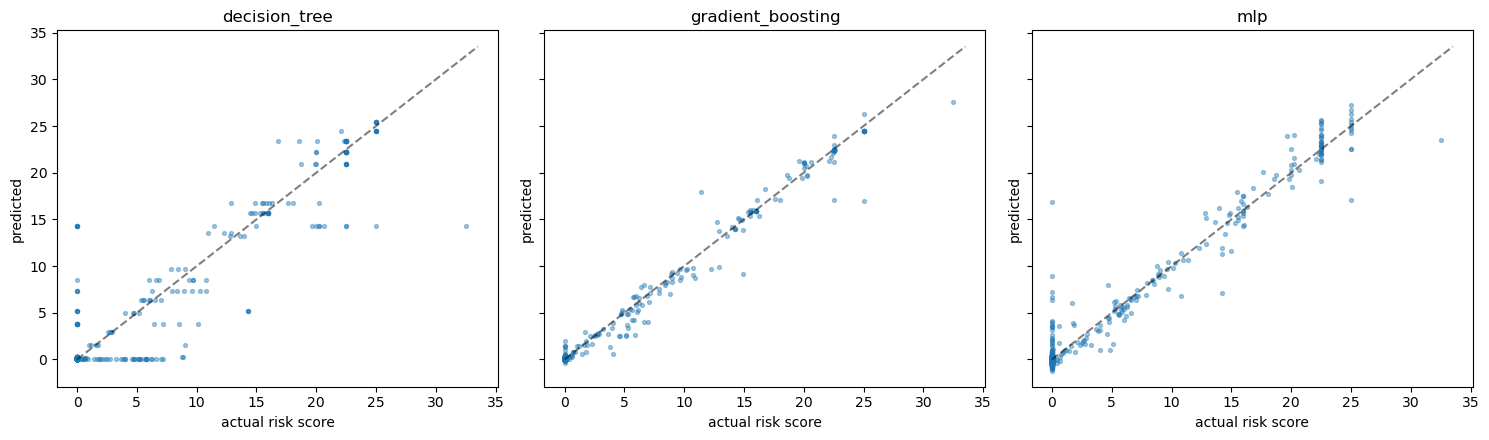

In [13]:
# Predicted vs actual risk score (test set) - one panel per regressor
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, name in zip(axes, REG_NAMES):
    yhat = test_pred_reg[name]
    ax.scatter(y_test_reg, yhat, s=8, alpha=0.4)
    lim = [0, max(y_test_reg.max(), yhat.max()) + 1]
    ax.plot(lim, lim, "k--", alpha=0.5)
    ax.set_title(name); ax.set_xlabel("actual risk score"); ax.set_ylabel("predicted")
plt.tight_layout(); plt.show()


## 9. Compare and contrast

- **Best classifier** is typically **Gradient Boosting** — highest ROC-AUC and PR-AUC. Its interaction-capturing ability fits the multiplicative road-type × weather logic in the risk rule.
- **Decision Tree** trails on AUC but wins on **interpretability**: a single short tree exposes the threshold structure (e.g. "snow ≥ X AND temp ≤ Y") — valuable for safety review.
- **MLP** underperforms here because the dataset is small for a neural net and the categorical → one-hot inputs aren't ideal for a dense network. It would catch up with more data and/or feature embeddings.
- For **regression**, Gradient Boosting and the Decision Tree both achieve high R² because the target is largely a deterministic function of the inputs. MLP regression tends to be noisier without further tuning.
- **Loss vs. proper score:** log-loss and Brier score show models are reasonably *calibrated*; not perfectly, which is something a calibration step (`CalibratedClassifierCV`) would address in production.

## 10. Metrics that don't apply

- **Semantic Match** is an NLP / embedding similarity metric for free-text outputs (RAG, summarisation). The ForeRoute prediction task is tabular — classification of segment hazard and regression of a risk score — so semantic match has no operational meaning here.
- **Plain accuracy** is reported for completeness but is a weak summary because the dataset is imbalanced. We rely on **PR-AUC** and **recall at the safety threshold** as the headline metrics.

## 11. Production deployment challenges

1. **Concept and data drift on weather.** OpenWeatherMap units, station coverage, and forecast horizons change over time. We need rolling-window retraining and a feature-level drift monitor (e.g. PSI per week) before each release.
2. **Serving topology.** Today the model is served via `mlflow models serve` (single Flask process). For production we should build a Docker image with `mlflow models build-docker`, deploy behind an autoscaler, and budget latency end-to-end: a single route requires *N* segments × OpenWeather latency, which dominates ML inference. A `(lat, lng, hour)` cache cuts repeat calls.
3. **Threshold portability.** A recall-priority threshold tuned globally may be too aggressive in mild climates and too conservative in extreme ones. A practical next step is region- or season-specific thresholds, or a calibrated probability surfaced directly in the UI.
4. **Graceful degradation.** The product's Next.js orchestrator already falls back to the deterministic rule-based risk score whenever MLflow is unreachable. This preserves a safety story during outages or rollouts.
5. **Explainability.** Each surfaced prediction is paired with rule-based factors (snow severity, ice risk, etc.) and can be augmented with SHAP attributions on the ML score, keeping decisions auditable.
6. **Label realism.** Our labels are stochastic derivations of an engineered rule. In a real deployment we should swap this for outcome-based labels (incident reports, observed slow-downs, telematics anomalies) and re-train periodically.
7. **Privacy and quota.** Routes carry user location; the weather API has rate limits. Inference should run server-side with anonymised coordinates and queue-bounded fan-out to stay within quota.

## 12. Reproducibility note

This notebook is mirrored by the production training pipeline at `ml/train.py`, which runs the same algorithms with MLflow autolog, registers the best model as `ForeRoute-SegmentRisk@production`, and the Next.js web app (`web/app/api/routes/route.ts`) consumes that model through MLflow's `/invocations` endpoint at request time.